In [1]:
import os
import sys
sys.path.insert(0, os.getcwd())
import sinter
from ldpc.sinter_decoders import SinterBeliefFindDecoder, SinterBpOsdDecoder

from src.cached_bposd_sinter import CachedBpOsdSinterDecoder
from src.stabilizer_code import extract, bb_code
from src.simulate import tostim, detector_error_model_gauge
from src.stim_native_circuit import build_css_stim_circuit, build_bb_stim_tasks_noise

from lib.TrapSIMD.sabre_iontrap import *
from lib.TrapSIMD.grid_iontrap import *

In [2]:
path = "./QEC-Code"

In [3]:
code_name = "BB-code"
stab_fname = os.path.join(path, f"{code_name}.stab")
bb_code(stab_fname)
is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)



(12, 72)


In [4]:
def gen_noise_profile2(p_trans = 2 * 10 ** (-4)):
    noise_profile = {
        "intra-move": p_trans,
        "intra-swap": p_trans,
        "inter-move": 2 * p_trans,
        "inter-swap": 4 * p_trans,
        # Scale 2q-gate noise with the swept p_trans so x-axis sweep matters.
        "2q-gate": (18.3 * 10 ** (-4) / (2 * 10 ** (-4))) * p_trans
    }
    return noise_profile 

In [5]:
import time

# Match GenCode style: BB Qiskit schedule -> TrapSIMD grid routing -> Stim + sinter
D = 5
L = 3
CZ = 3
draw_flag = False

noise_list = [2e-4, 1.5e-4, 1e-4]
tasks = []

# BB-code parameters (kept fixed, like a single-distance GenCode run)
ell = 6
m = 6
d_label = ell

# Qiskit iter controls number of syndrome rounds; we also use it as "r" for plotting.
rounds = 4

code_name = "BB-code"
stab_fname = os.path.join(path, f"{code_name}.stab")

t0 = time.time()
# Write .stab for the requested BB size.
bb_code(stab_fname, ell=ell, m=m)
print(f"bb_code: {time.time() - t0:.1f}s")

t1 = time.time()
is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)
print(f"extract(iter={rounds}): {time.time() - t1:.1f}s")

# Deterministic alternative: Z-only syndrome extraction using Stim-native
# BB schedule. We keep the logical-Z observable from the data M results.
z_stabilizers = [s for s in stabilizers if all(gate[1] == "Z" for gate in s["Ctrl"])]

for p in noise_list:
    tp = time.time()
    noise_profile = build_bb_stim_tasks_noise(gen_noise_profile2(p))
    stim_circ = build_css_stim_circuit(
        z_stabilizers,
        noise_profile,
        dataNum,
        rounds=rounds,
        L=L,
        observable_mode="transversal",
    )

    tasks.append(
        sinter.Task(
            circuit=stim_circ,
            json_metadata={"d": d_label, "r": rounds, "p": p},
        )
    )
    print(f"stim-native(z-only) p={p:.1e}: {time.time() - tp:.1f}s")

print(f"built {len(tasks)} tasks in {time.time() - t0:.1f}s")

(12, 72)
bb_code: 0.0s
extract(iter=4): 0.0s
stim-native(z-only) p=2.0e-04: 1.2s
stim-native(z-only) p=1.5e-04: 0.8s
stim-native(z-only) p=1.0e-04: 0.8s
built 3 tasks in 2.9s


In [6]:
# Rebuild tasks for multiple BB distances (to get 3+ curves like GenCode)
import time

tasks = []
ell_list = [4, 5, 7]
code_name = "BB-code"

t0 = time.time()
for ell in ell_list:
    m = ell
    rounds = ell * 3
    stab_fname = os.path.join(path, f"{code_name}-{ell}.stab")

    bb_code(stab_fname, ell=ell, m=m)
    is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)

    z_stabilizers = [s for s in stabilizers if all(gate[1] == "Z" for gate in s["Ctrl"])]

    for p in noise_list:
        noise_profile = build_bb_stim_tasks_noise(gen_noise_profile2(p))
        stim_circ = build_css_stim_circuit(
            z_stabilizers,
            noise_profile,
            dataNum,
            rounds=rounds,
            L=L,
            observable_mode="transversal",
        )

        tasks.append(
            sinter.Task(
                circuit=stim_circ,
                json_metadata={"d": ell, "r": rounds, "p": p},
            )
        )

print(f"rebuilt {len(tasks)} tasks in {time.time() - t0:.1f}s")


(0, 32)
(0, 50)
(0, 98)
rebuilt 9 tasks in 25.0s


In [7]:
tasks[0].circuit

stim.Circuit('''
    R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31
    DEPOLARIZE1(0.00183) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31
    R 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
    DEPOLARIZE1(0.00183) 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
    TICK
    DEPOLARIZE1(0.00183) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31
    CX 1 32 4 32
    DEPOLARIZE2(0.00183) 1 32 4 32
    CX 2 32 8 32
    DEPOLARIZE2(0.00183) 2 32 8 32
    CX 3 32 12 32
    DEPOLARIZE2(0.00183) 3 32 12 32
    TICK
    CX 0 33 5 33
    DEPOLARIZE2(0.00183) 0 33 5 33
    CX 2 33 9 33
    DEPOLARIZE2(0.00183) 2 33 9 33
    CX 3 33 13 33
    DEPOLARIZE2(0.00183) 3 33 13 33
    TICK
    CX 0 34 6 34
    DEPOLARIZE2(0.00183) 0 34 6 34
    CX 1 34 10 34
    DEPOLARIZE2(0.00183) 1 34 10 34
    CX 3 34 14 34
    DEPOLARIZE2(0.00183) 3 34 14 34
    TICK
    CX 0 35 7 35
    DEPOLARIZ

In [8]:
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=["bposd"],
    custom_decoders={"bposd": CachedBpOsdSinterDecoder()},
    max_shots=200_000,
    max_errors=200,
    print_progress=True,
)

Starting 4 workers...
9 tasks left:
  workers decoder eta shots_left errors_left json_metadata     
        1   bposd   ?     200000         200 d=4,r=12,p=0.0002 
        1   bposd   ?     200000         200 d=4,r=12,p=0.00015
        1   bposd <1m     199983         195 d=4,r=12,p=0.0001 
        1   bposd   ?     200000         200 d=5,r=15,p=0.0002 
        0   bposd ?·∞     200000         200 d=5,r=15,p=0.00015
        0   bposd ?·∞     200000         200 d=5,r=15,p=0.0001 
        0   bposd ?·∞     200000         200 d=7,r=21,p=0.0002 
        0   bposd ?·∞     200000         200 d=7,r=21,p=0.00015
        0   bposd ?·∞     200000         200 d=7,r=21,p=0.0001 
9 tasks left:
  workers decoder eta shots_left errors_left json_metadata     
        1   bposd <1m     199983         197 d=4,r=12,p=0.0002 
        1   bposd <1m     199983         195 d=4,r=12,p=0.00015
        1   bposd <1m     199983         195 d=4,r=12,p=0.0001 
        1   bposd <1m     199999         199 d=5,r=15,

In [9]:
# Decoder diagnostics: quick sanity check + tiny speed benchmark
import time

print(f"tasks: {len(tasks)}")
for i, t in enumerate(tasks):
    md = t.json_metadata
    print(f"task[{i}] p={md['p']} r={md['r']} d={md['d']}")

bench_task = tasks[0]

t0 = time.time()
bench_pm = sinter.collect(
    num_workers=1,
    tasks=[bench_task],
    decoders=["bposd"],
    custom_decoders={"bposd": CachedBpOsdSinterDecoder()},
    max_shots=50,
    print_progress=False,
)
print(f"bposd benchmark: {time.time() - t0:.2f}s for 50 shots")
print(bench_pm[0])

tasks: 9
task[0] p=0.0002 r=12 d=4
task[1] p=0.00015 r=12 d=4
task[2] p=0.0001 r=12 d=4
task[3] p=0.0002 r=15 d=5
task[4] p=0.00015 r=15 d=5
task[5] p=0.0001 r=15 d=5
task[6] p=0.0002 r=21 d=7
task[7] p=0.00015 r=21 d=7
task[8] p=0.0001 r=21 d=7
bposd benchmark: 0.88s for 50 shots
        50,        13,         0,   0.414,bposd,52dfa06c494c1b2f0bade5538014d7dbd9f26c9118ceec4e80637f02870333ab,"{""d"":4,""p"":0.0002,""r"":12}",


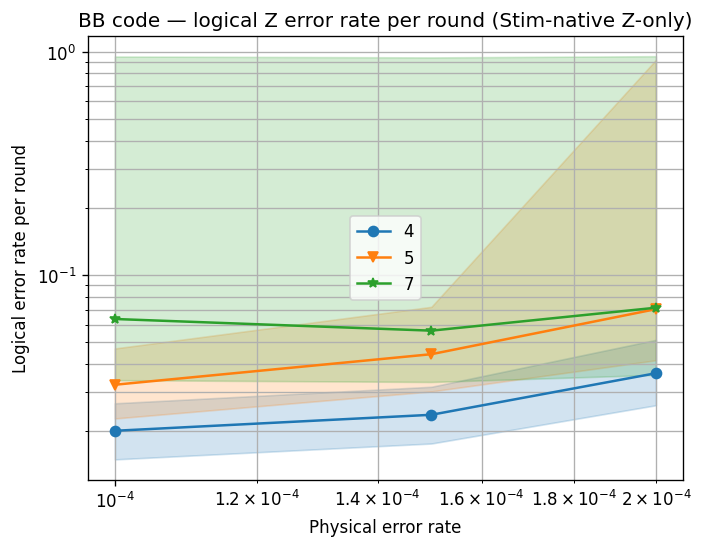

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)

sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda st: st.json_metadata["p"],
    failure_units_per_shot_func=lambda st: st.json_metadata["r"],
    group_func=lambda st: st.json_metadata["d"],
)

ax.loglog()
ax.set_title("BB code — logical Z error rate per round")
ax.set_xlabel("Physical error rate")
ax.set_ylabel("Logical error rate per round")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)